# 07 — Sample weight, Multi-Output และ TimeSeriesSplit

ผลทั้งหมดมาจาก `python -m src.train_multi` (Train = 2023, Dev = 2024, CV อยู่ภายในช่วง 2023–2024) **ไม่ได้โหลดข้อมูลปี 2025 เลย**
notebook นี้อ่านตารางผลที่บันทึกไว้ใน `docs/` และโหลดโมเดล multi-output ที่บันทึกไว้มาวิเคราะห์ต่อ

**กฎเลือก sample_weight (ประกาศไว้ในแผนวัน 7 ก่อนดูผล):**
1. ตัดแบบที่ MAE บนสเกล UVI แย่กว่าค่าต่ำสุดเกิน 0.02 ออก
2. จากแบบที่เหลือ เลือกแบบที่ค่าเฉลี่ยของ recall ระดับ**สูงมาก**กับ**รุนแรงมาก**สูงที่สุด
3. ถ้าเสมอกัน เลือกแบบที่ MAE ต่ำกว่า

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> source_code/ -> Final-Project/
sys.path.insert(0, str(ROOT / "source_code"))

FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# reference palette (dataviz skill): fixed categorical order, recessive axes
C_OM, C_NASA, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 100,
})


def save(fig, name):
    """Save a figure to docs/figures at 150 dpi."""
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")


In [2]:
import json

import joblib

from src.metrics import regression_metrics
from src.splits import chronological_split, load_model_data
from src.train_cmf import MODEL_DIR, load_spec
from src.train_multi import predict_multi

docs = ROOT / "docs"
weights = pd.read_csv(docs / "weight_experiment_dev_2024.csv")
cv = pd.read_csv(docs / "cv_folds_2023_2024.csv", parse_dates=["train_end", "val_start", "val_end"])
leaks = pd.read_csv(docs / "leakage_checks.csv")
metrics = json.loads((MODEL_DIR / "cmf_multi_xgb_v1_metrics.json").read_text(encoding="utf-8"))
weights.round(3)

,scheme,uvi_mae,uvi_rmse,uvi_r2,uvi_bias,who_accuracy,recall_Very high,recall_Extreme,selected
0,none,0.462,0.718,0.943,0.040,0.831,0.791,0.113,False
1,uvi_clear,0.459,0.716,0.943,0.037,0.832,0.788,0.094,False
2,uvi_clear^2,0.461,0.720,0.942,0.051,0.833,0.796,0.113,True


## 1. ผลการถ่วงน้ำหนัก (XGBoost CMF_UVI, train 2023 → dev 2024)

C:\Users\folkt\AppData\Local\Temp\ipykernel_24164\1781158421.py:30: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")
C:\Users\folkt\AppData\Local\Temp\ipykernel_24164\1781158421.py:30: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")
C:\Users\folkt\AppData\Local\Temp\ipykernel_24164\1781158421.py:30: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")
C:\Users\folkt\AppData\Local\Temp\ipykernel_24164\1781158421.py:30: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")
C:\Users\folkt\AppData\Local\Temp\ipykernel_24164\1781158421.py:30: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) De

selected: uvi_clear^2


C:\Users\folkt\ML-CPE\Final-Project\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\folkt\ML-CPE\Final-Project\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\folkt\ML-CPE\Final-Project\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\folkt\ML-CPE\Final-Project\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\folkt\ML-CPE\Final-Project\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\

C:\Users\folkt\ML-CPE\Final-Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\folkt\ML-CPE\Final-Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\folkt\ML-CPE\Final-Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\folkt\ML-CPE\Final-Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\folkt\ML-CPE\Final-Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 3585 (\N

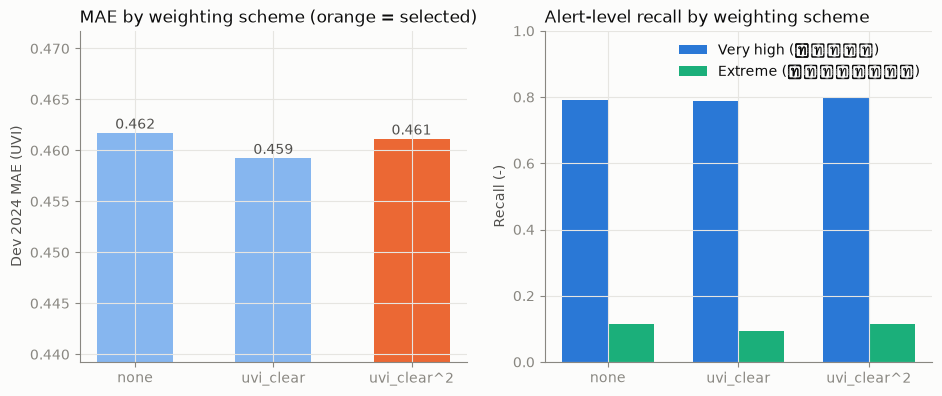

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
x = np.arange(len(weights))
colors = [C_NASA if s else "#86b6ef" for s in weights["selected"]]
axes[0].bar(x, weights["uvi_mae"], color=colors, width=0.55)
axes[0].set_xticks(x, weights["scheme"])
axes[0].set_ylim(weights["uvi_mae"].min() - 0.02, weights["uvi_mae"].max() + 0.01)
axes[0].set_ylabel("Dev 2024 MAE (UVI)")
axes[0].set_title("MAE by weighting scheme (orange = selected)", loc="left")
for i, v in enumerate(weights["uvi_mae"]):
    axes[0].annotate(f"{v:.3f}", (i, v), textcoords="offset points", xytext=(0, 3), ha="center", color=INK2)
w = 0.35
axes[1].bar(x - w / 2, weights["recall_Very high"], width=w, color=C_OM, label="Very high (สูงมาก)")
axes[1].bar(x + w / 2, weights["recall_Extreme"], width=w, color=C_THIRD, label="Extreme (รุนแรงมาก)")
axes[1].set_xticks(x, weights["scheme"])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Recall (-)")
axes[1].set_title("Alert-level recall by weighting scheme", loc="left")
axes[1].legend(loc="upper right")
save(fig, "cv_weight_experiment.png")
print("selected:", metrics["sample_weight"]["scheme"])

## 2. TimeSeriesSplit 5 folds (2023–2024, gap 12 แถว ≈ 1 วัน)

In [4]:
cols = ["uvi_mae", "uvi_rmse", "uvi_r2", "uvi_bias", "recall_Very high", "recall_Extreme", "uva_mae_wm2", "uvb_mae_wm2"]
summary = pd.DataFrame({"mean": cv[cols].mean(), "std": cv[cols].std()}).T
display_cols = ["fold", "val_start", "val_end", "n_train", "n_val"] + cols
print(cv[display_cols].to_string(index=False, float_format="%.3f"))
summary.round(3)

 fold                 val_start                   val_end  n_train  n_val  uvi_mae  uvi_rmse  uvi_r2  uvi_bias  recall_Very high  recall_Extreme  uva_mae_wm2  uvb_mae_wm2
    1 2023-05-07 10:00:00+00:00 2023-08-28 05:00:00+00:00     1231   1239    0.507     0.781   0.943     0.006             0.762           0.412        3.196        0.095
    2 2023-08-28 06:00:00+00:00 2024-01-01 10:00:00+00:00     2470   1239    0.585     0.808   0.914    -0.444             0.388           0.333        3.222        0.097
    3 2024-01-02 02:00:00+00:00 2024-05-06 08:00:00+00:00     3709   1239    0.454     0.704   0.947    -0.051             0.803           0.038        2.802        0.085
    4 2024-05-06 09:00:00+00:00 2024-08-27 04:00:00+00:00     4948   1239    0.537     0.805   0.935     0.022             0.799           0.200        3.408        0.100
    5 2024-08-27 05:00:00+00:00 2024-12-31 10:00:00+00:00     6187   1239    0.383     0.610   0.951     0.122             0.786           0.000 

,uvi_mae,uvi_rmse,uvi_r2,uvi_bias,recall_Very high,recall_Extreme,uva_mae_wm2,uvb_mae_wm2
mean,0.493,0.742,0.938,-0.069,0.708,0.197,3.048,0.090
std,0.078,0.084,0.015,0.219,0.179,0.179,0.329,0.011


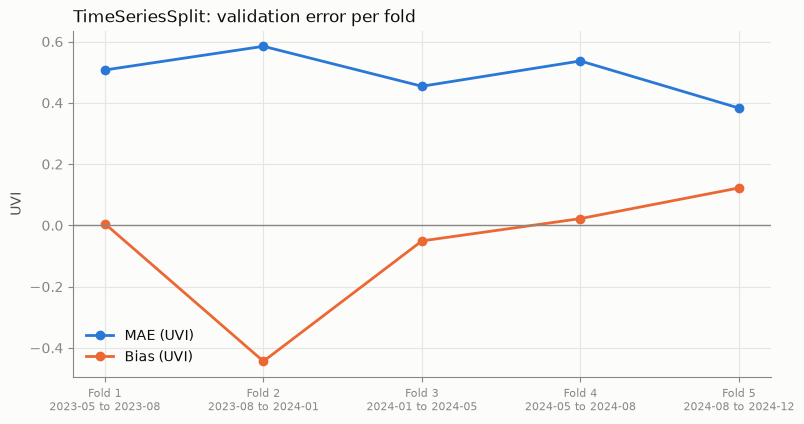

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = [f"{r.val_start:%Y-%m} to {r.val_end:%Y-%m}" for r in cv.itertuples()]
ax.plot(cv["fold"], cv["uvi_mae"], color=C_OM, marker="o", ms=6, label="MAE (UVI)")
ax.plot(cv["fold"], cv["uvi_bias"], color=C_NASA, marker="o", ms=6, label="Bias (UVI)")
ax.axhline(0, color=MUTED, lw=1)
ax.set_xticks(cv["fold"], [f"Fold {k}\n{l}" for k, l in zip(cv["fold"], labels)], fontsize=8)
ax.set_ylabel("UVI")
ax.set_title("TimeSeriesSplit: validation error per fold", loc="left")
ax.legend(loc="lower left")
save(fig, "cv_folds.png")

## 3. UVA / UVB จากโมเดล multi-output (dev 2024)

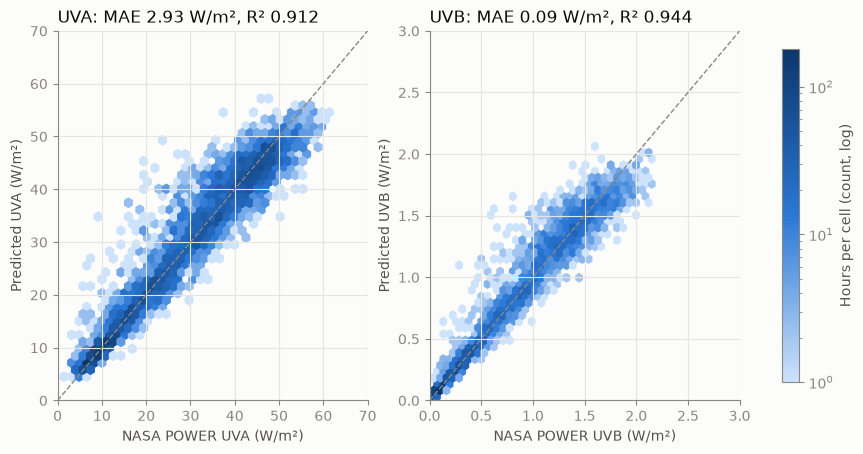

In [6]:
features = load_spec()["features"]
_, dev = chronological_split(load_model_data())
model = joblib.load(MODEL_DIR / "cmf_multi_xgb_v1.joblib")
pred = predict_multi(model, dev[features])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, target, num, den, band, lim in [(axes[0], "cmf_a", "nasa_uva_wm2", "uva_clear", "UVA", 70),
                                        (axes[1], "cmf_b", "nasa_uvb_wm2", "uvb_clear", "UVB", 3)]:
    est = dev[den] * pred[target]
    m = regression_metrics(dev[num], est)
    hb = ax.hexbin(dev[num], est, gridsize=35, mincnt=1, bins="log",
                   cmap=LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#2a78d6", "#0d366b"]))
    ax.plot([0, lim], [0, lim], color=MUTED, lw=1, ls="--")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel(f"NASA POWER {band} (W/m²)"); ax.set_ylabel(f"Predicted {band} (W/m²)")
    ax.set_title(f"{band}: MAE {m['mae']:.2f} W/m², R² {m['r2']:.3f}", loc="left")
fig.colorbar(hb, ax=axes, shrink=0.9, label="Hours per cell (count, log)")
save(fig, "cv_uva_uvb_dev2024.png")

## 4. ผลตรวจ data leakage

In [7]:
leaks

,check,passed,detail
0,no test-year (2025) rows,True,0 rows >= 2025
1,features exclude NASA / targets / denominators,True,none
2,"folds chronological, gap kept, no shared times...",True,fold 1: gap 12 rows; fold 2: gap 12 rows; fold...
3,no feature with |Spearman| > 0.95 vs cmf_uvi,True,max 0.656 (direct_radiation)
4,shuffled-target model R² <= 0.05,True,R² -0.105


## สรุป

1. **sample_weight แทบไม่ต่างกัน:** MAE บน dev 2024 อยู่ที่ 0.459–0.462 และ recall ระดับรุนแรงมากอยู่ที่ 0.09–0.11 ในทั้ง 3 แบบ ตามกฎที่ประกาศไว้ได้แบบ **`uvi_clear²`** (ค่าเฉลี่ย recall ของระดับเตือนสูงสุด 0.455) แต่ความต่างอยู่ในระดับ noise **สมมติฐานว่าการถ่วงน้ำหนักจะแก้ปัญหาทำนาย CMF เที่ยงวันต่ำไปจึงไม่เป็นจริง** ที่ยังใช้ `uvi_clear²` ต่อเพราะตรงกับ loss บนสเกล UVI ในทางทฤษฎีและเป็นไปตามกฎ ไม่ใช่เพราะช่วยได้จริง
2. **สาเหตุที่ recall ระดับรุนแรงมากต่ำ:** ในชั่วโมงระดับรุนแรงมาก ค่า NASA เฉลี่ยแค่ 10.98 ซึ่งอยู่เหนือเส้นแบ่ง 10.5 เพียงเล็กน้อย ขณะที่โมเดลทำนายได้ราว 9.7 แค่ประเมินต่ำไป ~1 UVI ก็ตกไปอยู่ระดับสูงมากทั้งหมดแล้ว เป็นปัญหาของค่ากลางที่อยู่ใกล้เส้นแบ่ง ไม่ใช่เรื่องน้ำหนักของข้อมูล **วิธีที่ถูกคือเตือนด้วย q90 ในวัน 9** ตามที่ rules กำหนด
3. **Multi-output (dev 2024):** UVI MAE 0.461 (R² 0.942) เท่ากับโมเดลที่ทำนาย target เดียวในวัน 6 ส่วน UVA MAE ~2.9 W/m² และ UVB MAE ~0.086 W/m²
4. **TimeSeriesSplit:** MAE เฉลี่ย ≈ 0.49 ± 0.08 UVI **fold 2 (ก.ย.–ธ.ค. 2023) แย่ที่สุด** (bias −0.44, recall ระดับสูงมาก 0.39) เพราะฝึกด้วยข้อมูลแค่ ม.ค.–ส.ค. จึงไม่เคยเห็นช่วงปลายฝนต้นหนาว แสดงว่าต้องใช้ข้อมูลอย่างน้อย 1 ปีเต็มให้ครบทุกฤดู ซึ่งสนับสนุนการ refit บน 2023–2024 ในวัน 10 ส่วน recall ระดับรุนแรงมากในแต่ละ fold แกว่งมาก (0.00–0.41) เพราะแต่ละ fold มีชั่วโมงระดับนี้น้อย
5. **Leakage:** ผ่านทั้ง 5 ข้อ
   - ไม่มีแถวของปี 2025
   - ไม่มี feature ต้องห้าม
   - fold เรียงตามเวลาและมี gap 12 แถว
   - |Spearman| สูงสุด 0.66 (`direct_radiation`)
   - โมเดลที่ฝึกกับ target สุ่มสลับได้ R² −0.10 บน validation

   feature ทุกตัวเป็นค่าของชั่วโมงเดียวกันจาก Open-Meteo หรือคำนวณจากเวลา/ตำแหน่ง ไม่มี lag หรือ rolling
